# Classical vs quantum queries

This notebook shows three family of plots:

* how does the spectral gap $\delta(n, \beta)$ scales as a function of $n$ (for fixed $\beta$) and as a function of $\beta$ (for fixed $n$);
* how does the number of classical queries scales, for different trial moves, as function of $n$ and for fixed allowed error $\varepsilon$ in TV distance; also, how does the scaling compares asyntotiacally with the inverse spectral gap;
* how does the number of classical queries compares to the number of quantum queries, as function of $n$ and for fixed allowed error $\varepsilon$ in TV distance.

In [6]:
# allows us to have visibility on our package without installing it in editing mode
import sys;
if ".." not in sys.path: sys.path.append("..")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Merge simulation results

If you have just cloned the repo from Github, you may find a lot of smaller files in the data folder. These are the results of the parallelization of the simulations, and must be merged into a single file. We cannot merge them at the git level because versioning handle large binary files quite badly. 

In [4]:
from monaqa2.data.utils_pandas import merge_pickle_dataframes

In [5]:
_ = merge_pickle_dataframes([
    Path("../data/classical_queries_n3_idx0to100.pkl"),
    Path("../data/classical_queries_n4_idx0to100.pkl"),
    Path("../data/classical_queries_n5_idx0to100.pkl"),
    Path("../data/classical_queries_n6_idx0to100.pkl"),
    Path("../data/classical_queries_n7_idx0to50.pkl"),
    Path("../data/classical_queries_n7_idx50to100.pkl"),
    Path("../data/classical_queries_n8_idx0to20.pkl"),
    Path("../data/classical_queries_n8_idx20to40.pkl"),
    Path("../data/classical_queries_n8_idx40to60.pkl"),
    Path("../data/classical_queries_n8_idx60to80.pkl"),
    Path("../data/classical_queries_n8_idx80to100.pkl"),
    Path("../data/classical_queries_n9_idx0to10.pkl"),
    Path("../data/classical_queries_n9_idx10to20.pkl"),
    Path("../data/classical_queries_n9_idx20to30.pkl"),
    Path("../data/classical_queries_n9_idx30to40.pkl"),
    Path("../data/classical_queries_n9_idx40to50.pkl"),
    Path("../data/classical_queries_n9_idx50to60.pkl"),
    Path("../data/classical_queries_n9_idx60to70.pkl"),
    Path("../data/classical_queries_n9_idx70to80.pkl"),
    Path("../data/classical_queries_n9_idx80to90.pkl"),
    Path("../data/classical_queries_n9_idx90to100.pkl"),
    Path("../data/classical_queries_n10_idx0to100.pkl"),
], Path("../data/classical_queries_merged.pkl"))

In [5]:
_ = merge_pickle_dataframes([
    Path("../data/spectral_gaps_n3_idx0to100.pkl"), 
    Path("../data/spectral_gaps_n4_idx0to100.pkl"), 
    Path("../data/spectral_gaps_n5_idx0to100.pkl"), 
    Path("../data/spectral_gaps_n6_idx0to100.pkl"), 
    Path("../data/spectral_gaps_n7_idx0to100.pkl"), 
    Path("../data/spectral_gaps_n8_idx0to100.pkl"), 
    Path("../data/spectral_gaps_n9_idx0to5.pkl"), 
    Path("../data/spectral_gaps_n9_idx5to10.pkl"), 
    Path("../data/spectral_gaps_n9_idx10to20.pkl"), 
    Path("../data/spectral_gaps_n9_idx20to30.pkl"), 
    Path("../data/spectral_gaps_n9_idx30to40.pkl"), 
    Path("../data/spectral_gaps_n9_idx40to50.pkl"), 
    Path("../data/spectral_gaps_n9_idx50to60.pkl"), 
    Path("../data/spectral_gaps_n9_idx60to70.pkl"), 
    Path("../data/spectral_gaps_n9_idx70to80.pkl"), 
    Path("../data/spectral_gaps_n9_idx80to90.pkl"), 
    Path("../data/spectral_gaps_n9_idx90to100.pkl"), 
    Path("../data/spectral_gaps_n10_idx0to100.pkl"), 
], Path("../data/spectral_gaps_merged.pkl"))

## Statistics 

* `mean+std`:
* `mean+std-tail`:
* `median+mad`:

## Spectral gap plots

The spectral gap plots must match the behaviour of figure xx in xxx. 

Specifically:
* no need to be monotonic in $\beta$

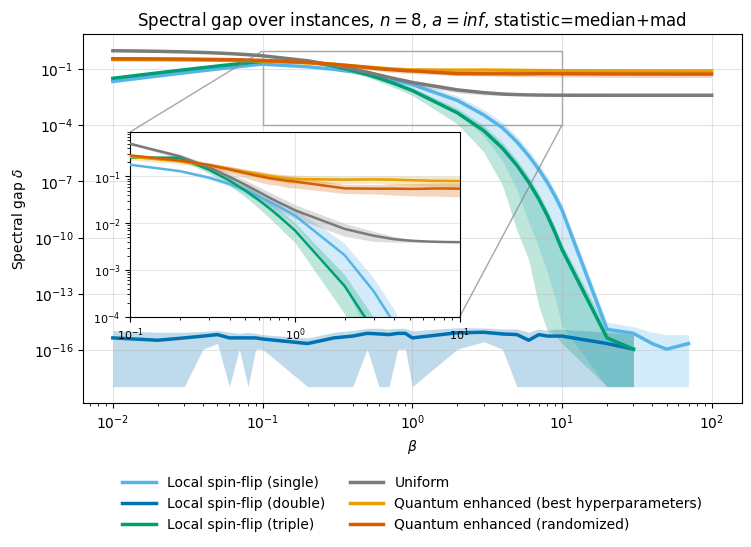

In [19]:
from monaqa2.data.plot_delta_vs_beta import plot_spectral_gap_vs_beta

n = 8                  # from 3 to 10
a = np.inf             # either np.inf (MH acceptance) or 1 or 10 (glauber)
statistic = "median+mad" # "mean+std", "mean+std-tail", or "median+mad"
fig, ax = plot_spectral_gap_vs_beta(n=n, a=a, statistic=statistic)

We see scaling as $2^{O(n)}$ but...

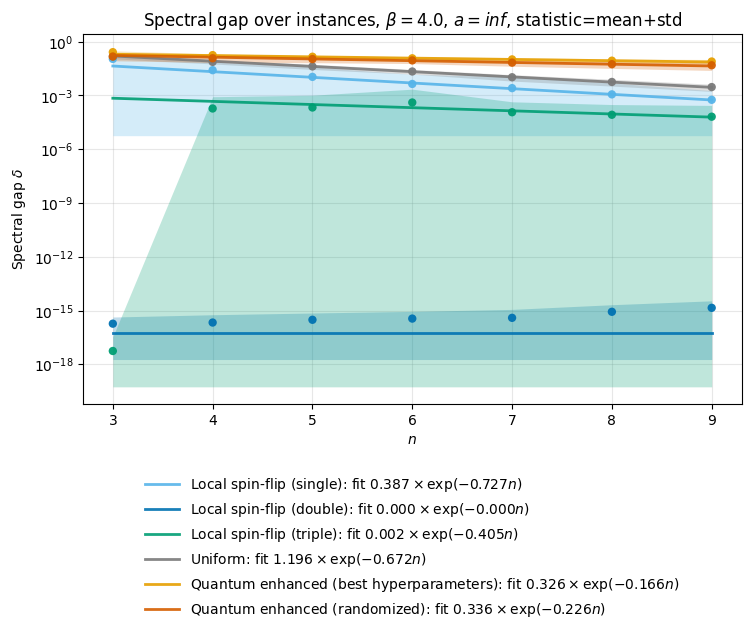

In [20]:
from monaqa2.data.plot_delta_vs_n import plot_spectral_gap_vs_n

beta = 4.0
a = np.inf             # either np.inf (MH acceptance) or 1 or 10 (glauber)
statistic = "mean+std" # "mean+std", "mean+std-tail", or "median+mad"
fig, ax = plot_spectral_gap_vs_n(beta=beta, a=np.inf, statistic=statistic, n_fit_min=5, n_fit_max=8)

At different $\beta$ we have different speedup. Specifically...

In [9]:
import numpy as np
import pandas as pd
from monaqa2.data.filename import SPECTRAL_GAP_FILE
from monaqa2.data.spectral_gap import get_spectral_gap_fit

a, statistic, n_min, n_max = np.inf, "mean+std", 5, 10
props = ["uniform", "local1", "local2", "local3", "qemc", "layden"]
file = "../data/old_data/spectral_gap_old.pkl"  # SPECTRAL_GAP_FILE
betas = sorted(pd.read_pickle(file)["beta"].astype(float).unique())
betas = [beta for beta in betas if 1.0 <= beta <= 10.0]

rows = []
for beta in betas:
    row = {"beta": beta}
    for p in props:
        try:
            _, row[p] = get_spectral_gap_fit(p, a, beta, statistic=statistic, n_min=n_min, n_max=n_max, in_file=file)
        except ValueError:
            row[p] = np.nan
    best_classical = np.nanmin([row[p] for p in ["uniform", "local1", "local2", "local3"]])
    best_quantum  = np.nanmin([row[p] for p in ["qemc", "layden"]])
    row["speedup"] = best_classical / best_quantum
    rows.append(row)

table = pd.DataFrame(rows)
table

,beta,uniform,local1,local2,local3,qemc,layden,speedup
0,1.0,0.542913,0.313298,0.351446,0.393482,0.185354,0.169305,1.850492
1,2.0,0.631537,0.426968,0.504097,0.534962,0.176820,0.195803,2.414708
2,3.0,0.654436,0.510343,0.585017,0.593359,0.163179,0.202215,3.127503
3,4.0,0.664051,0.579379,0.632883,0.624659,0.159149,0.205846,3.640481
4,5.0,0.669239,0.645699,0.665738,0.643331,0.158077,0.208610,4.069735
5,6.0,0.672462,0.711590,0.689139,0.654763,0.158133,0.210483,4.140579
6,7.0,0.674657,0.774924,0.706048,0.662140,0.158546,0.211736,4.176339
7,8.0,0.676257,0.842305,0.719797,0.667429,0.159141,0.212714,4.193948
8,9.0,0.677486,0.912497,0.731922,0.670966,0.159705,0.213264,4.201275
9,10.0,0.678470,0.989846,0.741417,0.673434,0.160205,0.213648,4.203569


## Classical monte carlo query model

## Classical queries vs spectral gap

With smaller epsilon we get close to the spectral gap behaviour

In [7]:
from monaqa2.data.plot_classical_query_vs_n import plot_classical_query_vs_n

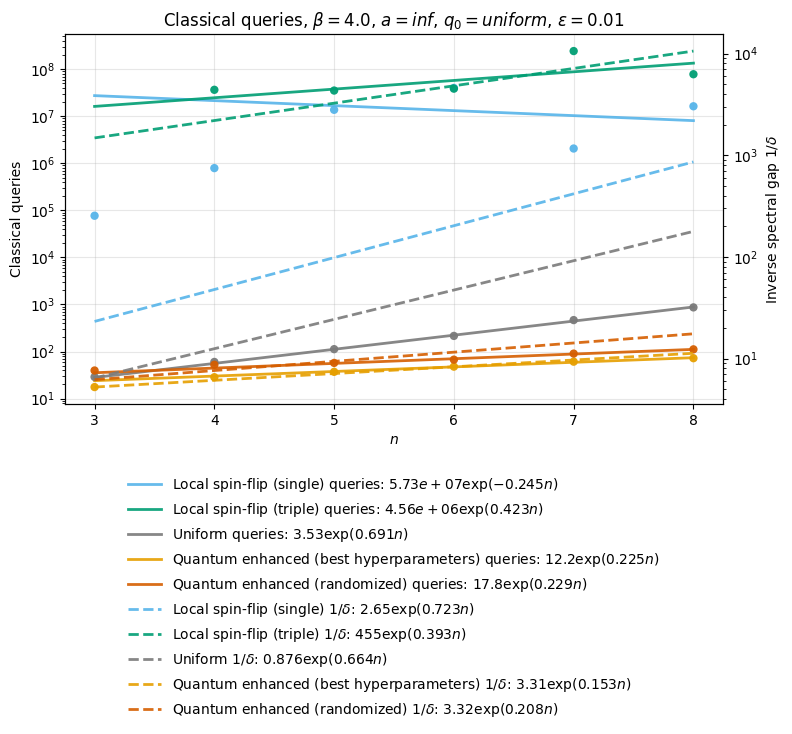

In [9]:
beta = 4.0
a = np.inf             # either np.inf (MH acceptance) or 1 or 10 (glauber)
statistic = "mean+std" # "mean+std", "mean+std-tail", or "median+mad"
q0_mode = "uniform"    # "uniform" or "bhattacharyya"
eps = 1e-2             # just this one in the old file

show_sg = True

_ = plot_classical_query_vs_n(beta=beta, a=a, q0_mode=q0_mode, epsilon=eps, statistic=statistic, show_spread=False, show_inverse_gap=show_sg, n_fit_min=5, n_fit_max=10)

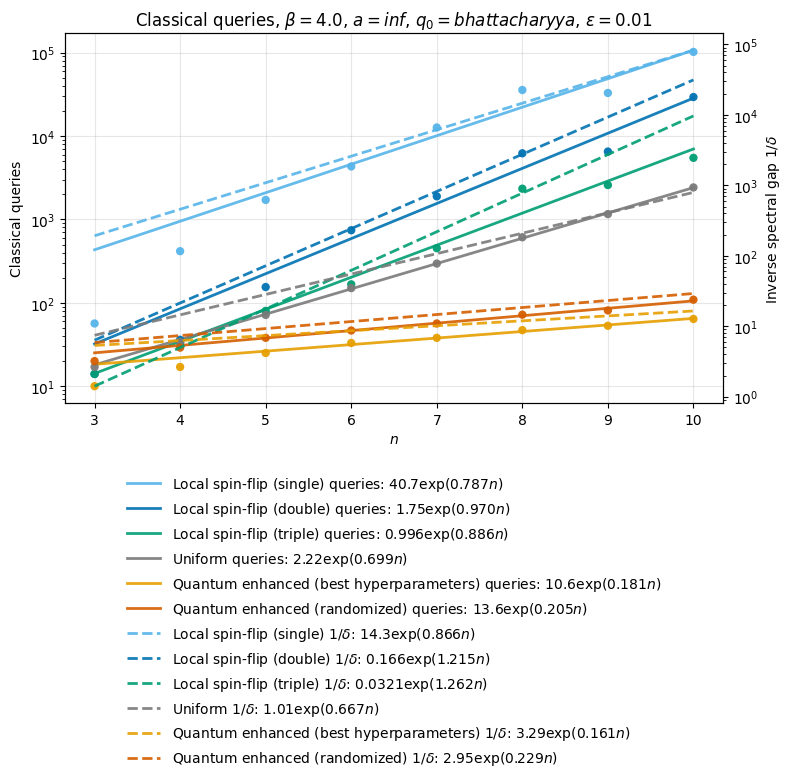

In [15]:
beta = 4.0
a = np.inf                 # either np.inf (MH acceptance) or 1 or 10 (glauber)
statistic = "median+mad"   # "mean+std", "mean+std-tail", or "median+mad"
q0_mode = "bhattacharyya"  # "uniform" or "bhattacharyya"
eps = 1e-2                 # just this one in the old file

classical_queries_file = "../data/old_data/classical_queries_old.pkl"
spectral_gap_file = "../data/old_data/spectral_gap_old.pkl"
show_sg = True

_ = plot_classical_query_vs_n(beta=beta, a=a, q0_mode=q0_mode, epsilon=eps, classical_query_file=classical_queries_file, spectral_gap_file=spectral_gap_file, statistic=statistic, show_spread=False, show_inverse_gap=show_sg, n_fit_min=5, n_fit_max=10)

## Classical queries vs quantum queries

Starting from the uniform distribution is not ok for quantum. 

Quadratic speedup at parity of the distribution. 

Uniform classical vs annealing quantum.

## Quantum QPE-based query model

We assume the quantum algorithm to be implemented as a spectral filter that uses Quantum Phase Estimation to eigendecompose an initial distribution $q_0$ encoded coherently, $\ket{q_0}$, onto the eigenvectors of the Szegedy quantum walk operator $W$ with a precision larger than the phase gap. A post-selection onto the eigenvalue register of the eigenphase $0$ ensure we reach the stationary distribution of the Markov chain. 

We count queries to $W$. For a classical spectral gap $\delta(n,\beta)$, define the relevant Szegedy phase gap (consider the half-step walk convention with walk eigenphases $\pm \arccos(\lambda)$) as

$$
\Delta_\phi(n,\beta)
=
\arccos(1-\delta(n,\beta)).
$$

Since the nontrivial eigenvalue closest to $1$ is $\lambda_\star=1-\delta$, the smallest nonzero phase is $\Delta_\phi = \arccos(1-\delta) \approx \sqrt{2 \delta}$. Using standard QPE with an $M$-point phase grid, the angular resolution is approximately $2\pi/M$, 

$$
C(n,\beta)
=
\left\lceil
\frac{2\pi}{\Delta_\phi(n,\beta)}
\right\rceil
=
\left\lceil
\frac{2\pi}{\arccos(1-\delta(n,\beta))}
\right\rceil.
$$

In analogy with the classical algorithm, we study the process of converging to the stationary distribution starting either from the **uniform distribution** or from a **warm-started distribution**; the latter is a state $\ket{\pi_{\beta_0}}$ encoding the stationary distribution of the same chain albeit at a smaller inverse temperature $\beta_0 < \beta$ target, and such that $|\braket{\pi_{\beta_0}}{\pi_\beta}|^2 \ge \alpha^2 = 1/e$. 

### Warm-start mode (overlap guarantee on the initial distribution)

Here the target distribution is $\pi_\beta$, while the initial distribution is already close to it, for example $\pi_{\beta_0}$ with $\beta_0<\beta$. The overlap is the Bhattacharyya coefficient $ \alpha(\beta_0,\beta) = \langle \pi_\beta|\pi_{\beta_0}\rangle = \sum_x \sqrt{\pi_\beta(x)\pi_{\beta_0}(x)}$. The success probability of projecting from $|\pi_{\beta_0}\rangle$ onto $|\pi_\beta\rangle$ is $ p_{\mathrm{warm}} = |\alpha(\beta_0,\beta)|^2$. 

$$
Q_{\mathrm{warm}}(n,\beta)
=
\frac{C(n, \beta)}{|\alpha(\beta_0,\beta)|^2}
$$

### Annealing mode (uniform distribution as initial state)

In the uniform-started mode, the initial state is the infinite-temperature Gibbs state, $|\pi_0\rangle = 2^{-n/2}\sum_x |x\rangle$. Directly projecting from $|\pi_0\rangle$ to $|\pi_\beta\rangle$ may have exponentially small success probability. Instead, introduce an annealing schedule $0=\beta_0<\beta_1<\cdots<\beta_L=\beta$.

For the transition $t\to t+1$, write $|s\rangle = |\pi_{\beta_t}\rangle$ for the source state, $|d\rangle = |\pi_{\beta_{t+1}}\rangle$ for the destination state, $\alpha = \langle d|s\rangle$ for their overlap, and $p = |\alpha|^2$. We denote by $\Pi_s = |s\rangle\langle s|$ and $\Pi_d = |d\rangle\langle d|$ the projectors onto the respective states.

The QPE cost of implementing $\Pi_s$ is denoted $C_t(n)$, and the QPE cost of implementing $\Pi_d$ is denoted $C_{t+1}(n)$, where

$$
C_t(n)
=
\left\lceil
\frac{2\pi}{\arccos(1-\delta(n,\beta_t))}
\right\rceil.
$$

Choosing phases such that $\alpha=\sqrt{p}$, the two states $|s\rangle$ and $|d\rangle$ span a two-dimensional subspace, and we can write

$$
|s\rangle
=
\sqrt{p}\, |d\rangle
+
\sqrt{1-p}\,|d^\perp\rangle.
$$

1. Start from $|s\rangle$ and measure $\Pi_d$. We obtain:
    - the target state $|d\rangle$ with probability $p$;
    - the failed branch $|d^\perp\rangle$ with probability $1-p$.

2. If the first projection fails, measure the old projector $\Pi_s$. The orthogonal branch decomposes as $|d^\perp\rangle = \sqrt{1-p}\,|s\rangle - \sqrt{p}\,|s^\perp\rangle$. Therefore we obtain:
    - the initial state $|s\rangle$ with probability $1-p$;
    - the failed branch $|s^\perp\rangle$ with probability $p$.

3. If the second projection succeeds, we have rewound successfully to $|s\rangle$, so the forward projection can be retried. If the second projection fails, note that $|s^\perp\rangle = \sqrt{1-p}\,|d\rangle - \sqrt{p}\,|d^\perp\rangle$, so we measure $\Pi_d$ again. Therefore we obtain:
    - the desired state $|d\rangle$ with probability $1-p$;
    - the failed branch $|d^\perp\rangle$ with probability $p$.

For the three expected costs of applying QPE starting from $|s\rangle$, $|d^\perp\rangle$, and $|s^\perp\rangle$, denoted by $E_s$, $E_{d^\perp}$, and $E_{s^\perp}$, respectively, we have:
- $E_s = C_{t+1}(n) + (1 - p) E_{d^\perp}$;
- $E_{d^\perp} = C_t(n) + (1 - p) E_s + p E_{s^\perp}$;
- $E_{s^\perp} = C_{t+1}(n) + p E_{d^\perp}$.

Solving these three linear equations gives

$$
E_s
=
C_{t+1}(n)
+
\frac{C_t(n)+C_{t+1}(n)}{2p}.
$$

The total expected number of Szegedy-walk queries for the full annealing schedule is therefore

$$
Q_{\mathrm{anneal}}(n,\beta)
=
\sum_{t=0}^{L-1}
\left[
C_{t+1}(n)
+
\frac{C_t(n)+C_{t+1}(n)}{2p_{t+1}}
\right].
$$

It does not really matter here to use fixed-point amplitude amplification to push the dependency from the success probability from $\frac{1}{p} \approx 2.71$ to $\frac{1}{\sqrt p} \approx 1.65$ as the enhance dependency in this variable is largely compensated by the overhead of the procedure (and longer circuits, with more challenging angle synthesis and qec implementation...). 

Note that assuming non-increasing spectral gap we have:

$$
Q_{\mathrm{anneal}}(n,\beta)
=
\sum_{t=0}^{L-1}
\left[
C_{t+1}(n)
+
\frac{C_t(n)+C_{t+1}(n)}{2p_{t+1}}
\right]
\le 
5.44 \, \sqrt n \, C_L(n)
$$

### Generation

Here you MUST choose a statistic because it will be used to determine the spectral gap, it is log-linear interpolated. 

In [1]:
from monaqa2.data.quantum_query import run_experiment_to_generate_quantum_queries
# run_experiment_to_generate_quantum_queries(n_list=range(3, 11), skip_most_acceptance=True, statistic="mean+std")

ModuleNotFoundError: No module named 'monaqa2'

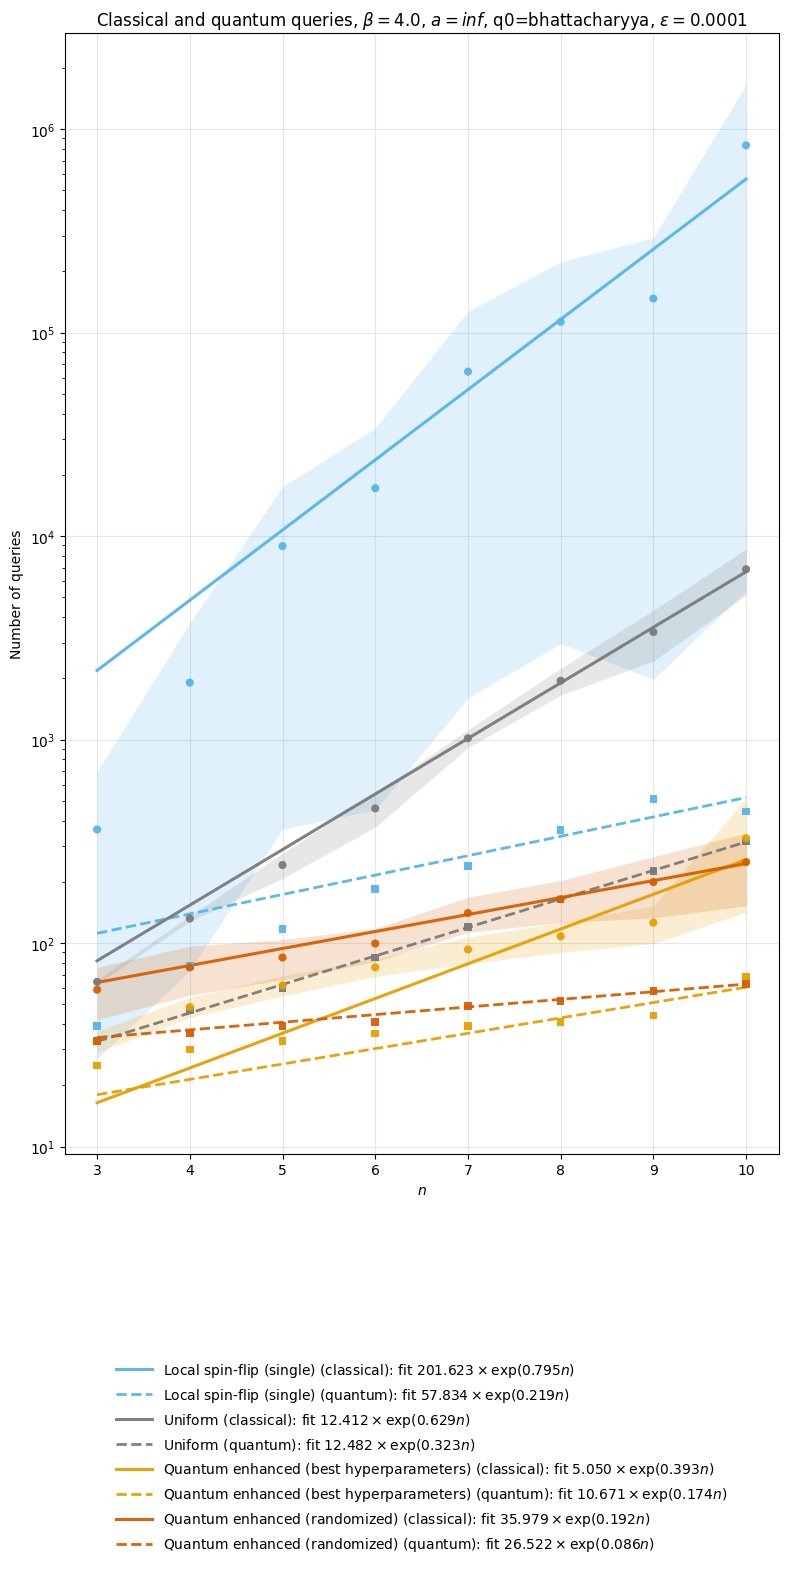

In [17]:
from monaqa2.data.filename import CLASSICAL_QUERY_FILE, QUANTUM_QUERY_FILE
from monaqa2.data.plot_classical_query_and_quantum_query_vs_n import plot_classical_and_quantum_queries

fig, ax = plot_classical_and_quantum_queries(
    beta=4.0,
    a=np.inf,
    q0_mode="bhattacharyya",
    epsilon=1e-4,
    classical_query_file=CLASSICAL_QUERY_FILE,
    quantum_query_file=QUANTUM_QUERY_FILE,
    statistic="median+mad",
    show_spread=True,
    min_count=1,
    n_fit_min=7,
    n_fit_max=10,
)

fig.set_size_inches(8, 16)
fig.tight_layout()
plt.show()

In [ ]:
detecting and defining quantum speedup tryoer ronnow (2014)